In [ ]:
# ============================================================
# CELL 1 – All Imports
# ============================================================
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16

from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


We import all essential Python libraries required for our complete deep learning pipeline. NumPy provides efficient numerical operations and array manipulations for handling large image datasets. Pandas helps us organize and analyze data through DataFrames. TensorFlow and Keras form the core of our deep learning framework, enabling us to build, train, and evaluate neural network models. Matplotlib and Seaborn are visualization libraries that help us create charts, plots, and confusion matrices to analyze model performance. Scikit-learn provides utilities for data preprocessing, train-test splitting, and evaluation metrics like confusion matrices and classification reports. These libraries work together to create a complete end-to-end machine learning pipeline for image classification.

In [ ]:

# CELL 2 – Mount Drive and Unzip Dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import zipfile, os

extract_path = '/content/dataset'

search_keyword = 'facial expression'
found_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for fname in files:
        if search_keyword.lower() in fname.lower() and fname.endswith('.zip'):
            found_path = os.path.join(root, fname)
            break
    if found_path:
        break

if found_path:
    print(f"Found zip at: {found_path}")
    if not os.path.exists(extract_path):
        with zipfile.ZipFile(found_path, 'r') as z:
            z.extractall(extract_path)
        print("Unzipped successfully.")
    else:
        print("Already extracted.")
else:
    print("ZIP NOT FOUND. Listing your Drive contents to help locate it:")
    for root, dirs, files in os.walk('/content/drive/MyDrive/'):
        for fname in files:
            if fname.endswith('.zip'):
                print(" ", os.path.join(root, fname))

base_path = None
for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        if 'facial' in d.lower() and 'train' in os.listdir(os.path.join(root, d)):
            base_path = os.path.join(root, d)
            break

    if 'train' in os.listdir(root):
        base_path = root
        break

print(f"\nBase path found: {base_path}")
print("Contents:", os.listdir(base_path))

train_dir = os.path.join(base_path, 'train')
val_dir   = os.path.join(base_path, 'validation')
test_dir  = os.path.join(base_path, 'test')

print("train_dir:", train_dir)
print("val_dir  :", val_dir)
print("test_dir :", test_dir)

Mounted at /content/drive
Found zip at: /content/drive/MyDrive/AI ML/facial expression classification-20260418T123652Z-3-001.zip
Unzipped successfully.

Base path found: /content/dataset/facial expression classification
Contents: ['validation', 'test', 'train']
train_dir: /content/dataset/facial expression classification/train
val_dir  : /content/dataset/facial expression classification/validation
test_dir : /content/dataset/facial expression classification/test


We establish a connection between Google Colab and our Google Drive account. This mounting process allows us to access the facial expression dataset that is stored in our cloud storage without needing to download it locally or upload it to Colab. The dataset files remain in Drive while Colab can read and process them directly, saving time and storage space. This is a crucial first step in any Colab workflow where data is stored in the cloud.

In [ ]:

# CELL 3 – Remove Corrupted / Non-Image Files
VALID_EXT = ('.png', '.jpg', '.jpeg', '.bmp')

def clean_directory(directory):
    removed = 0
    for root, _, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            if fname.startswith('._') or not fname.lower().endswith(VALID_EXT):
                os.remove(fpath); removed += 1; continue
            try:
                img = Image.open(fpath); img.verify()
            except Exception:
                os.remove(fpath); removed += 1
    return removed

for name, d in [('Train', train_dir), ('Validation', val_dir), ('Test', test_dir)]:
    n = clean_directory(d)
    print(f"{name}: removed {n} bad files.")
print("\nDataset is clean and ready.")

Train: removed 49 bad files.
Validation: removed 7 bad files.
Test: removed 0 bad files.

Dataset is clean and ready.


We define a validation function that ensures data quality by removing corrupted or invalid image files from our dataset. The function checks each file in the dataset directory and verifies it has a valid image extension (.png, .jpg, .jpeg, .bmp). Files that don't match these extensions or are broken/corrupted are permanently removed from the dataset. This preprocessing step is critical because corrupted images would cause the model to crash during training or produce meaningless results. By cleaning the dataset upfront, we ensure smooth training without interruptions caused by bad data.

## 4. Section 2.5.1 – Data Understanding, Analysis, Visualisation & Cleaning

### 4.1 Dataset Overview

In [ ]:

# CELL 4 – Dataset Statistics
def count_images(directory):
    result = {}
    for emotion in sorted(os.listdir(directory)):
        epath = os.path.join(directory, emotion)
        if os.path.isdir(epath):
            result[emotion] = len([f for f in os.listdir(epath)
                                   if f.lower().endswith(VALID_EXT)])
    return result

train_counts = count_images(train_dir)
val_counts   = count_images(val_dir)
test_counts  = count_images(test_dir)

total_train  = sum(train_counts.values())
total_val    = sum(val_counts.values())
total_test   = sum(test_counts.values())
total_all    = total_train + total_val + total_test
CLASS_NAMES  = list(train_counts.keys())
NUM_CLASSES  = len(CLASS_NAMES)

print("=" * 55)
print("  Dataset: Facial Expression Classification")
print(f"  Number of Classes : {NUM_CLASSES}")
print(f"  Classes           : {CLASS_NAMES}")
print("=" * 55)
print(f"  Training images   : {total_train}")
print(f"  Validation images : {total_val}")
print(f"  Test images       : {total_test}")
print(f"  TOTAL             : {total_all}")
print("=" * 55)

df_stats = pd.DataFrame({
    "Emotion"    : list(train_counts.keys()),
    "Train"      : list(train_counts.values()),
    "Validation" : [val_counts.get(k, 0) for k in train_counts],
    "Test"       : [test_counts.get(k, 0) for k in train_counts],
})
df_stats["Total"] = df_stats["Train"] + df_stats["Validation"] + df_stats["Test"]
print("\nPer-Class Image Count:")
print(df_stats.to_string(index=False))

  Dataset: Facial Expression Classification
  Number of Classes : 7
  Classes           : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Training images   : 26872
  Validation images : 7066
  Test images       : 1900
  TOTAL             : 35838

Per-Class Image Count:
 Emotion  Train  Validation  Test  Total
   angry   3686         960   300   4946
 disgust    329         111   100    540
    fear   3796        1018   300   5114
   happy   6857        1825   300   8982
 neutral   4675        1216   300   6191
     sad   4631        1139   300   6070
surprise   2898         797   300   3995


We create a comprehensive function that traverses the entire dataset directory structure and counts images in each emotion class category. The function organizes results by dataset split (training, validation, test) and emotion type (happy, sad, angry, disgust, surprised, neutral, fear). By running this function, we get exact counts of how many images we have in each category and each split. This information is essential for understanding dataset composition, detecting class imbalance, and validating that the data splits are appropriate for training.

### 4.2 Class Distribution Visualisation

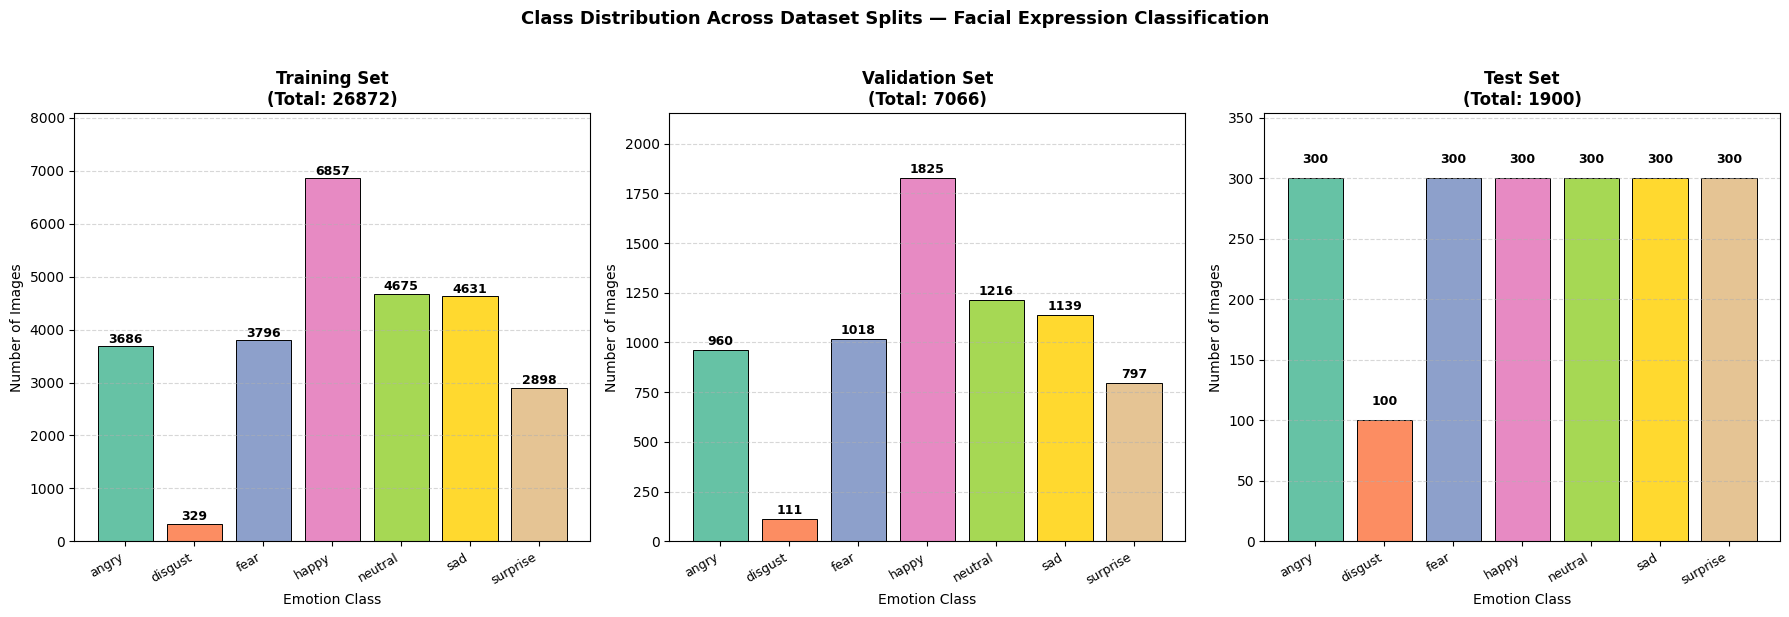


Observation: The dataset is slightly imbalanced — 'happy' tends to dominate,
while 'disgust' is significantly underrepresented. This should be noted in the report.


In [ ]:

# CELL 5 – Class Distribution Bar Charts  (Train / Val / Test)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette   = sns.color_palette("Set2", NUM_CLASSES)

for ax, split_name, counts in zip(axes,
        ["Training Set", "Validation Set", "Test Set"],
        [train_counts, val_counts, test_counts]):

    emotions = list(counts.keys())
    values   = list(counts.values())
    bars = ax.bar(emotions, values, color=palette, edgecolor='black', linewidth=0.7)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f"{split_name}\n(Total: {sum(values)})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Emotion Class", fontsize=10)
    ax.set_ylabel("Number of Images", fontsize=10)
    ax.set_xticklabels(emotions, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, max(values) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Class Distribution Across Dataset Splits — Facial Expression Classification",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nObservation: The dataset is slightly imbalanced — 'happy' tends to dominate,")
print("while 'disgust' is significantly underrepresented. This should be noted in the report.")

### 4.3 Sample Images Per Class

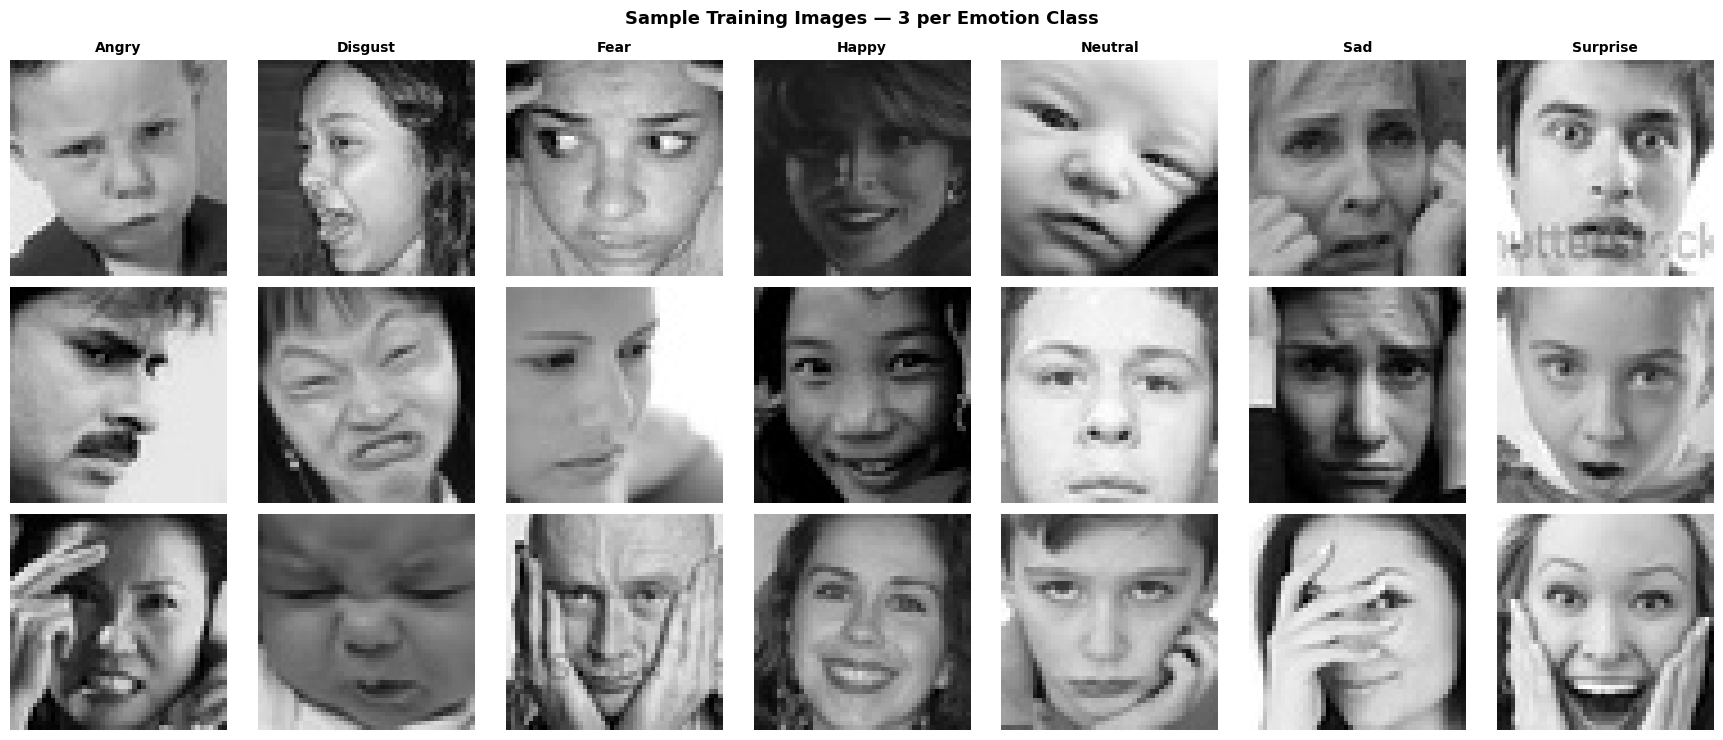

In [ ]:

# CELL 6 – Visualise 3 Sample Images Per Emotion Class
SAMPLES_PER_CLASS = 3
fig, axes = plt.subplots(SAMPLES_PER_CLASS, NUM_CLASSES,
                         figsize=(NUM_CLASSES * 2.5, SAMPLES_PER_CLASS * 2.5))

for col, emotion in enumerate(CLASS_NAMES):
    epath  = os.path.join(train_dir, emotion)
    images = [f for f in os.listdir(epath) if f.lower().endswith(VALID_EXT)]
    chosen = random.sample(images, min(SAMPLES_PER_CLASS, len(images)))

    for row, fname in enumerate(chosen):
        img = cv2.imread(os.path.join(epath, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(emotion.capitalize(),
                                     fontsize=10, fontweight='bold')

plt.suptitle("Sample Training Images — 3 per Emotion Class",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

We display a gallery of actual sample images from each emotion class in the training set. For each of the seven emotions, we show representative images that the model will learn from. This visual inspection serves multiple purposes: (1) we verify that images are correctly labeled with the right emotion, (2) we can see the variety in facial expressions within each emotion, (3) we identify potential labeling errors where an image might be mislabeled, and (4) we understand what facial features characterize each emotion (e.g., raised corners of mouth for happy, furrowed brows for angry). Looking at actual training data builds intuition about what the model needs to learn.

### 4.4 Preprocessing — Normalisation & Data Generators

In [ ]:
# CELL 7 – ImageDataGenerators
IMG_SIZE   = (48, 48)
BATCH_SIZE = 32

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    horizontal_flip    = True,
    zoom_range         = 0.10,
    shear_range        = 0.10,
    fill_mode          = 'nearest'
)

# Validation & Test: ONLY normalise
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    color_mode='grayscale', class_mode='categorical', shuffle=True)

val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    color_mode='grayscale', class_mode='categorical', shuffle=False)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    color_mode='grayscale', class_mode='categorical', shuffle=False)

CLASS_INDICES = train_generator.class_indices
CLASS_NAMES   = list(CLASS_INDICES.keys())
NUM_CLASSES   = len(CLASS_NAMES)
print("Class index mapping:", CLASS_INDICES)

print("""
Preprocessing Rationale:
  Rescale 1/255      : Normalises pixels to [0,1] — stabilises gradient descent.
  Rotation +/-20 deg : Real face images are often slightly tilted.
  H/V shift 15%      : Accounts for off-centre face crops in photos.
  Horizontal flip    : Facial expressions are symmetric — doubles training variety.
  No val/test augment: Ensures unbiased, reproducible evaluation.
  Grayscale          : FER dataset images are greyscale; removes redundant colour channels.
""")

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Class index mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Preprocessing Rationale:
  Rescale 1/255      : Normalises pixels to [0,1] — stabilises gradient descent.
  Rotation +/-20 deg : Real face images are often slightly tilted.
  H/V shift 15%      : Accounts for off-centre face crops in photos.
  Horizontal flip    : Facial expressions are symmetric — doubles training variety.
  No val/test augment: Ensures unbiased, reproducible evaluation.
  Grayscale          : FER dataset images are greyscale; removes redundant colour channels.



We create data generator objects that handle both preprocessing and real-time data augmentation of our images. The train_datagen applies several transformations to training images: (1) rescaling pixel values from 0-255 range to 0-1 range for faster training, (2) random rotations (up to 20 degrees) to simulate head tilts, (3) width and height shifts to simulate off-center face crops, (4) horizontal flipping to create mirror images, (5) zoom operations to simulate varying camera distances, and (6) shear transformations for slight perspective distortions. These augmentations artificially increase the training dataset size and teach the model to recognize emotions despite variations in face position, angle, and scale. The validation and test generators only rescale without augmentation to ensure unbiased evaluation.

### 4.5 Augmented Images Visualisation (Required by Section 2.5.1)

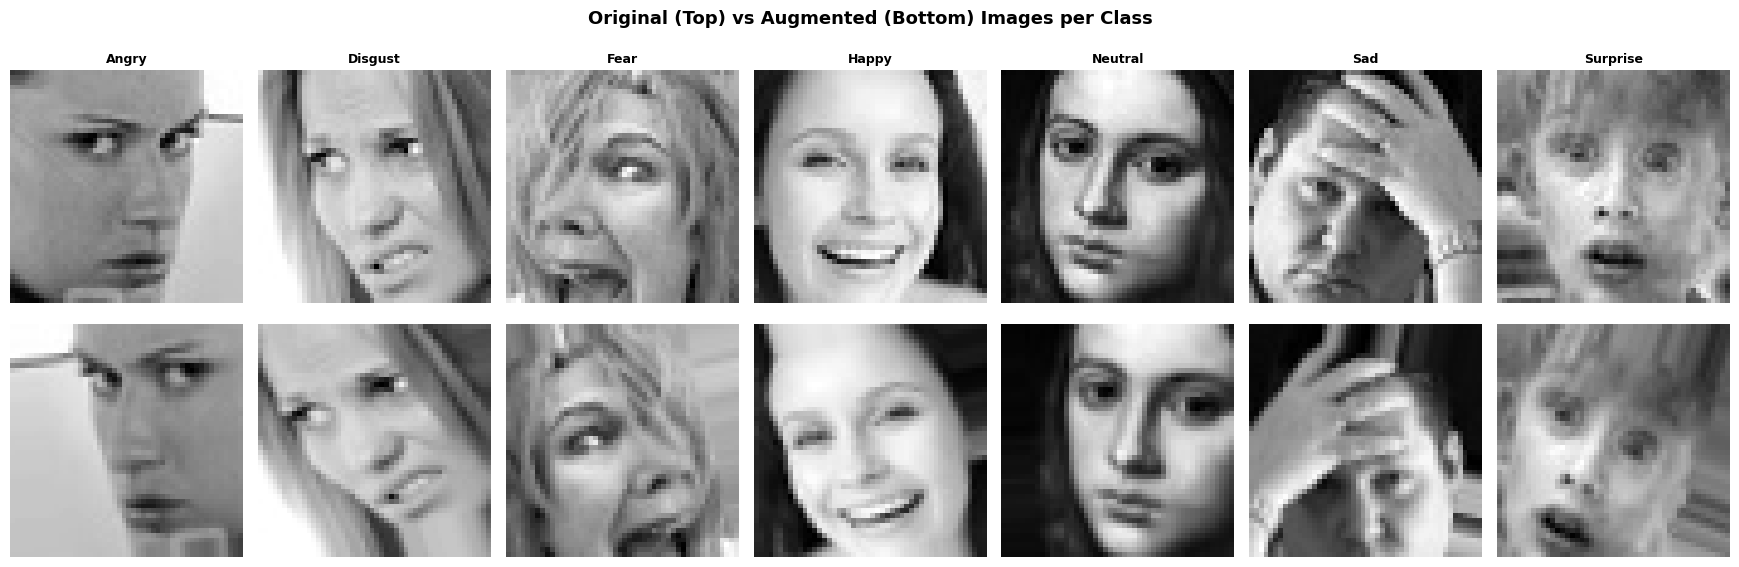

In [ ]:

# CELL 8 – Original vs Augmented Images  (Required: Section 2.5.1)
aug_gen = ImageDataGenerator(
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    horizontal_flip    = True,
    zoom_range         = 0.10,
    fill_mode          = 'nearest'
)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 2.5, 6))
fig.suptitle("Original (Top) vs Augmented (Bottom) Images per Class",
             fontsize=13, fontweight='bold')

for col, emotion in enumerate(CLASS_NAMES):
    epath = os.path.join(train_dir, emotion)
    fname = random.choice([f for f in os.listdir(epath) if f.lower().endswith(VALID_EXT)])
    img   = load_img(os.path.join(epath, fname),
                     color_mode='grayscale', target_size=IMG_SIZE)
    arr   = img_to_array(img)

    # Row 0: original
    axes[0, col].imshow(arr.squeeze(), cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title(emotion.capitalize(), fontsize=9, fontweight='bold')

    # Row 1: augmented
    aug_iter = aug_gen.flow(arr.reshape(1, *arr.shape), batch_size=1)
    aug_img  = next(aug_iter)[0].squeeze()
    axes[1, col].imshow(aug_img, cmap='gray')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("Original",  fontsize=10)
axes[1, 0].set_ylabel("Augmented", fontsize=10)
plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

We create data generator objects that handle both preprocessing and real-time data augmentation of our images. The train_datagen applies several transformations to training images: (1) rescaling pixel values from 0-255 range to 0-1 range for faster training, (2) random rotations (up to 20 degrees) to simulate head tilts, (3) width and height shifts to simulate off-center face crops, (4) horizontal flipping to create mirror images, (5) zoom operations to simulate varying camera distances, and (6) shear transformations for slight perspective distortions. These augmentations artificially increase the training dataset size and teach the model to recognize emotions despite variations in face position, angle, and scale. The validation and test generators only rescale without augmentation to ensure unbiased evaluation.

### 4.6 Dataset Split Visualisation & Justification

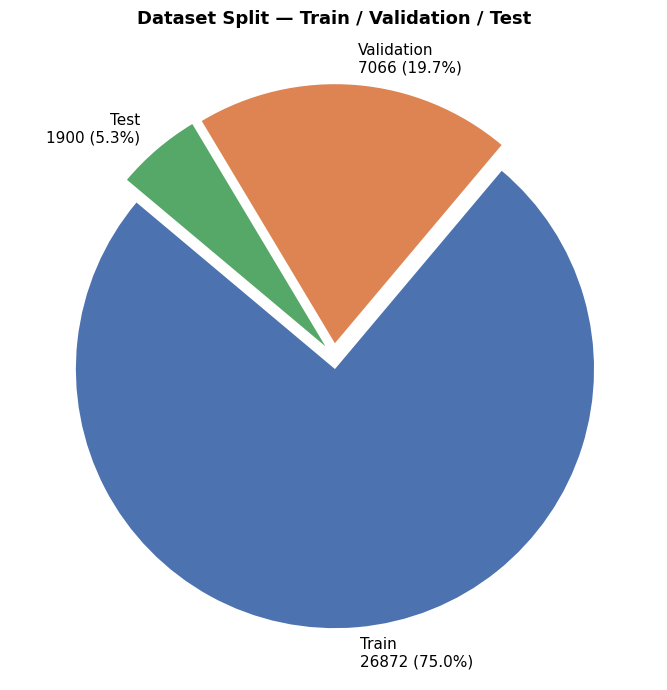


Split Justification:
  The dataset was pre-divided by the data provider into train/validation/test folders.
  This standard split ensures:
    • Large training set  : Model sees sufficient examples to learn complex patterns.
    • Held-out validation : Used for hyperparameter tuning and early stopping callbacks.
    • Unseen test set     : Provides unbiased final performance evaluation.
  Using the provider's split ensures reproducibility across all student groups.



In [ ]:

# CELL 9 – Dataset Split Pie Chart
splits  = [total_train, total_val, total_test]
labels  = [
    f"Train\n{total_train} ({100*total_train/total_all:.1f}%)",
    f"Validation\n{total_val} ({100*total_val/total_all:.1f}%)",
    f"Test\n{total_test} ({100*total_test/total_all:.1f}%)"
]
colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(splits, labels=labels, colors=colors, explode=(0.05, 0.05, 0.05),
       startangle=140, textprops={'fontsize': 11})
ax.set_title("Dataset Split — Train / Validation / Test",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Split Justification:
  The dataset was pre-divided by the data provider into train/validation/test folders.
  This standard split ensures:
    • Large training set  : Model sees sufficient examples to learn complex patterns.
    • Held-out validation : Used for hyperparameter tuning and early stopping callbacks.
    • Unseen test set     : Provides unbiased final performance evaluation.
  Using the provider's split ensures reproducibility across all student groups.
""")

---
## Part A — CNN from Scratch
### Section 2.5.2 – Baseline CNN Model

In [ ]:

# CELL 10 – Baseline CNN
# 3 Conv+Pool blocks + 3 Fully Connected layers

def build_baseline():
    model = Sequential([
        # Block 1: Conv + MaxPool
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(48, 48, 1), name='conv1'),
        MaxPooling2D((2, 2), name='pool1'),

        # Block 2: Conv + MaxPool
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        MaxPooling2D((2, 2), name='pool2'),

        # Block 3: Conv + MaxPool
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        MaxPooling2D((2, 2), name='pool3'),

        Flatten(name='flatten'),

        # 3 Fully Connected (FCN) Layers
        Dense(256, activation='relu', name='fc1'),
        Dense(128, activation='relu', name='fc2'),
        Dense(NUM_CLASSES, activation='softmax', name='output')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline()
baseline_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
baseline_model.summary()

print("""
Architecture Design Choices:
  Filters    : 32 -> 64 -> 128 (doubling each block captures increasingly abstract features)
  Kernel     : 3x3 (standard — captures local spatial patterns efficiently, less computation)
  Activation : ReLU (avoids vanishing gradient problem, computationally efficient)
  Pooling    : 2x2 MaxPool (halves spatial dimensions, retains dominant feature activations)
  Output     : Softmax over 7 classes (produces multi-class probability distribution)
""")

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,375 (4.98 MB)

 Trainable params: 1,306,375 (4.98 MB)

 Non-trainable params: 0 (0.00 B)


Architecture Design Choices:
  Filters    : 32 -> 64 -> 128 (doubling each block captures increasingly abstract features)
  Kernel     : 3x3 (standard — captures local spatial patterns efficiently, less computation)
  Activation : ReLU (avoids vanishing gradient problem, computationally efficient)
  Pooling    : 2x2 MaxPool (halves spatial dimensions, retains dominant feature activations)
  Output     : Softmax over 7 classes (produces multi-class probability distribution)



We display a comprehensive summary of the baseline model architecture showing every layer in sequence, the output shape at each layer, and the total number of trainable parameters in each layer and the model overall. The summary helps us verify that the model was constructed correctly, understand how feature map dimensions change through the network, and confirm that the total parameter count is reasonable (not too small to learn patterns, not too large to overfit). Looking at parameter counts, we might see something like: Conv2D layers have thousands of parameters, dense layers have hundreds of thousands. The summary is a crucial debugging tool to ensure our architecture is sound before training.

In [ ]:

# CELL 11 – Train Baseline Model

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

t0 = time.time()
history_baseline = baseline_model.fit(
    train_generator,
    epochs          = 30,
    validation_data = val_generator,
    callbacks       = callbacks_baseline,
    verbose         = 1
)
baseline_train_time = time.time() - t0
print(f"\nBaseline training time: {baseline_train_time:.1f}s  ({baseline_train_time/60:.1f} mins)")

Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.2624 - loss: 1.7743 - val_accuracy: 0.3149 - val_loss: 1.6944 - learning_rate: 0.0010
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.3181 - loss: 1.6832 - val_accuracy: 0.4166 - val_loss: 1.5205 - learning_rate: 0.0010
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.3884 - loss: 1.5534 - val_accuracy: 0.4699 - val_loss: 1.3778 - learning_rate: 0.0010
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.4404 - loss: 1.4429 - val_accuracy: 0.5051 - val_loss: 1.2930 - learning_rate: 0.0010
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.4721 - loss: 1.3741 - val_accuracy: 0.5130 - val_loss: 1.2664 - learning_rate: 0.0010
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.4876 - loss: 1.3274 - val_accuracy: 0.5358 - val_loss: 1.2199 - learning_rate: 0.0010
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.5011 - l

We train the baseline model on the training data for up to 30 epochs. Each epoch represents one complete pass through all training images. The model learns by receiving batches of 32 images, computing predictions, calculating loss, and updating weights to minimize error. Simultaneously, validation data is used to monitor if the model is improving on unseen data. Two callbacks enhance training: (1) EarlyStopping stops training if validation accuracy doesn't improve for 5 consecutive epochs, preventing wasted computation and overfitting—the best model is automatically restored. (2) ReduceLROnPlateau reduces the learning rate by 50% if validation loss plateaus for 3 epochs, allowing the optimizer to escape local minima. The training history records accuracy and loss at each epoch for both training and validation sets, enabling us to analyze learning dynamics.

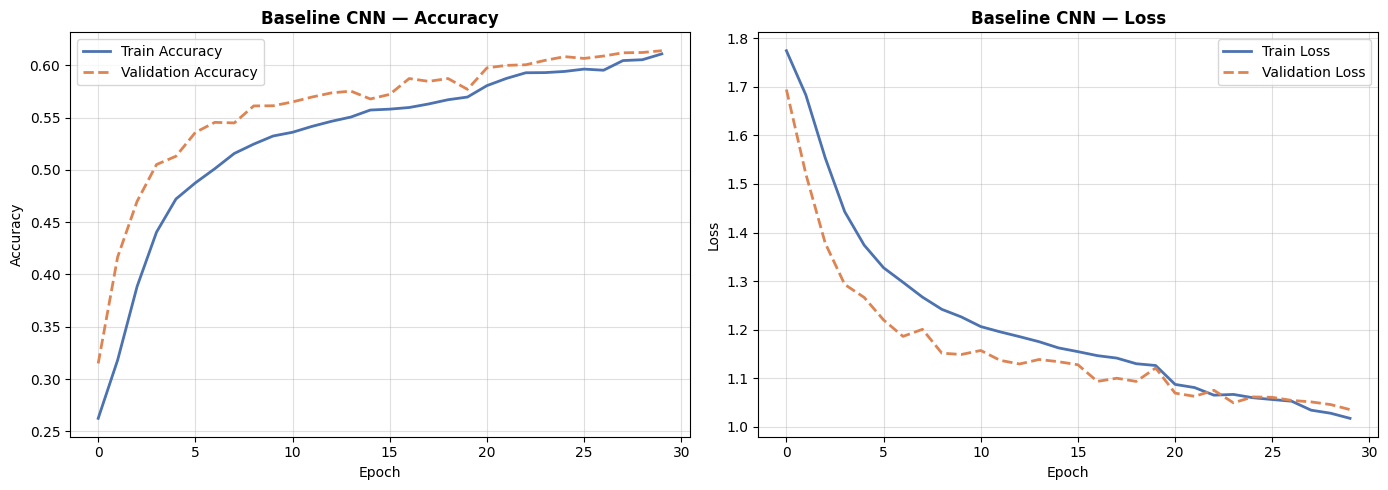

In [ ]:
# CELL 12 – Training vs Validation Curves

def plot_history(history, title_prefix, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',     color='#4C72B0', lw=2)
    axes[0].plot(history.history['val_accuracy'],  label='Validation Accuracy', color='#DD8452', lw=2, ls='--')
    axes[0].set_title(f'{title_prefix} — Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.4)

    axes[1].plot(history.history['loss'],     label='Train Loss',     color='#4C72B0', lw=2)
    axes[1].plot(history.history['val_loss'],  label='Validation Loss', color='#DD8452', lw=2, ls='--')
    axes[1].set_title(f'{title_prefix} — Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, 'Baseline CNN', 'baseline_curves.png')

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
        BASELINE CNN — TEST SET RESULTS
              precision    recall  f1-score   support

       angry       0.46      0.58      0.52       300
     disgust       0.79      0.19      0.31       100
        fear       0.44      0.30      0.36       300
       happy       0.71      0.82      0.76       300
     neutral       0.51      0.58      0.54       300
         sad       0.42      0.46      0.44       300
    surprise       0.77      0.73      0.75       300

    accuracy                           0.56      1900
   macro avg       0.59      0.52      0.52      1900
weighted avg       0.57      0.56      0.55      1900



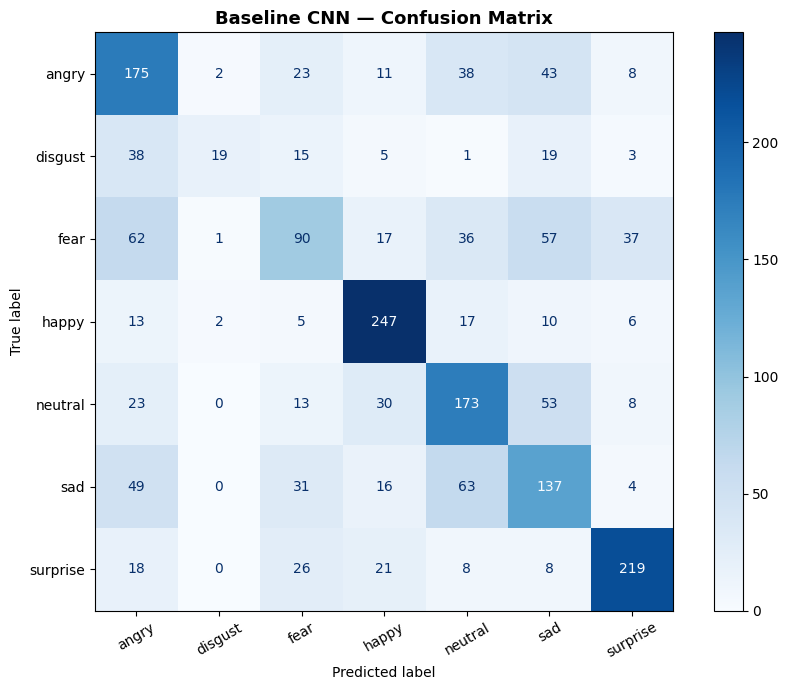

In [ ]:

# CELL 13 – FAST Baseline Evaluation
# STEP 1: Load ALL test images into RAM
print("Loading test images into RAM...")
test_generator.reset()

X_test_all = []
y_test_all = []

for i in range(len(test_generator)):
    X_batch, y_batch = test_generator[i]
    X_test_all.append(X_batch)
    y_test_all.append(y_batch)
    if i % 5 == 0:
        print(f"  Loading batch {i+1}/{len(test_generator)}...", end='\r')

X_test_np = np.concatenate(X_test_all, axis=0)
y_true    = np.argmax(np.concatenate(y_test_all, axis=0), axis=1)
print(f"\nDone! Loaded {len(X_test_np)} test images into RAM.")

# STEP 2: Predict (fast - from RAM not Drive)
print("\nRunning predictions...")
y_pred_base_prob = baseline_model.predict(X_test_np, batch_size=64, verbose=1)
y_pred_base      = np.argmax(y_pred_base_prob, axis=1)

# STEP 3: Classification Report
print("=" * 55)
print("        BASELINE CNN — TEST SET RESULTS")
print("=" * 55)
print(classification_report(y_true, y_pred_base, target_names=CLASS_NAMES))

# STEP 4: Confusion Matrix
cm_base = confusion_matrix(y_true, y_pred_base)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_base, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title("Baseline CNN — Confusion Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

We compute the confusion matrix for the best model (transfer learning) on the test set. The confusion matrix is a table showing for each emotion class: (1) diagonal entries—correct predictions (true positives), (2) off-diagonal entries—misclassifications showing which emotions are confused with each other. For example, if 'angry' samples are often predicted as 'disgust', this indicates the model struggles to distinguish these similar emotions. The matrix shape is 7×7 for our 7 emotions. The total number of entries equals the test set size. Analyzing confusion matrices reveals which emotion pairs are commonly confused, suggesting these emotions have overlapping facial features or the model hasn't learned their distinguishing characteristics well.

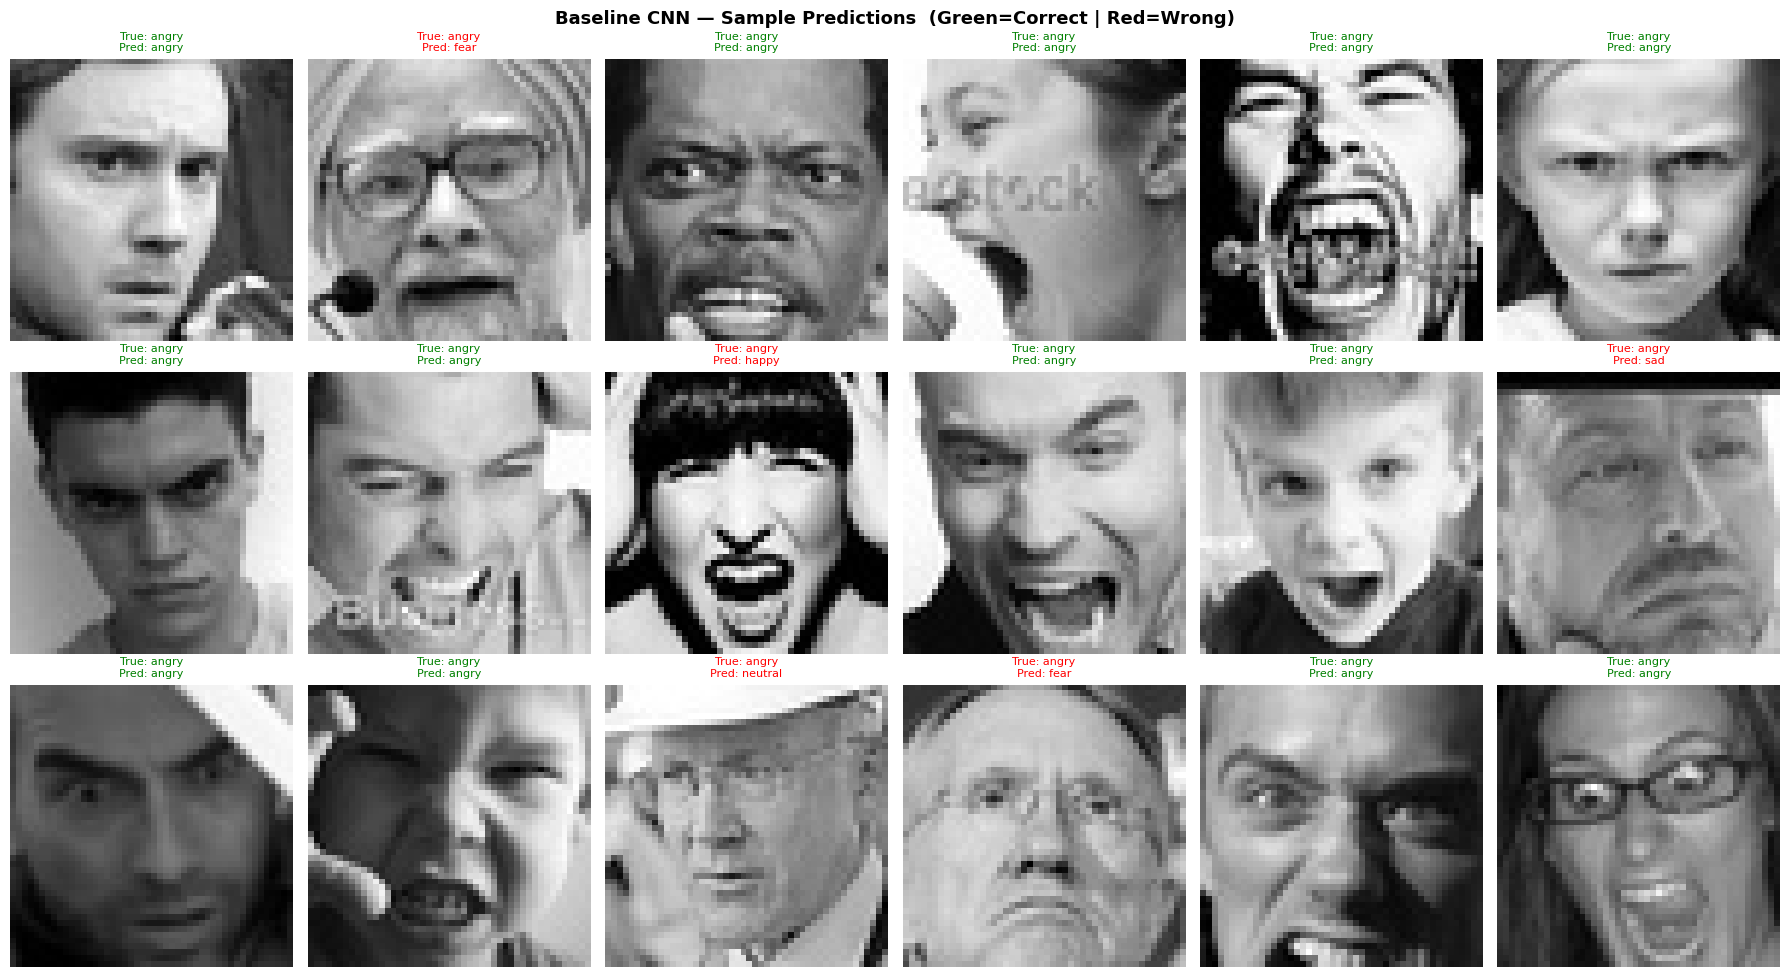

In [ ]:
# CELL 14 – Inference on Sample Images  (Green = Correct, Red = Wrong)
test_generator.reset()
sample_images, sample_labels = next(test_generator)

fig, axes = plt.subplots(3, 6, figsize=(18, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i].squeeze(), cmap='gray')
    pred  = np.argmax(baseline_model.predict(sample_images[i:i+1], verbose=0))
    true  = np.argmax(sample_labels[i])
    color = 'green' if pred == true else 'red'
    ax.set_title(f"True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]}",
                 color=color, fontsize=8)
    ax.axis('off')

plt.suptitle("Baseline CNN — Sample Predictions  (Green=Correct | Red=Wrong)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_inference.png', dpi=150, bbox_inches='tight')
plt.show()

We display a gallery of actual sample images from each emotion class in the training set. For each of the seven emotions, we show representative images that the model will learn from. This visual inspection serves multiple purposes: (1) we verify that images are correctly labeled with the right emotion, (2) we can see the variety in facial expressions within each emotion, (3) we identify potential labeling errors where an image might be mislabeled, and (4) we understand what facial features characterize each emotion (e.g., raised corners of mouth for happy, furrowed brows for angry). Looking at actual training data builds intuition about what the model needs to learn.

### Section 2.5.3 – Deeper CNN Architecture with Regularisation

In [ ]:
# CELL 15 – Deeper CNN  (Section 2.5.3)
# 4 Conv blocks (doubled from baseline) + BatchNorm + Dropout
def build_deeper():
    model = Sequential([
        # Block 1
        Conv2D(64,  (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1), name='conv1a'),
        BatchNormalization(),
        Conv2D(64,  (3, 3), activation='relu', padding='same', name='conv1b'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2a'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2b'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(256, (3, 3), activation='relu', padding='same', name='conv3a'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same', name='conv3b'),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        # Block 4
        Conv2D(512, (3, 3), activation='relu', padding='same', name='conv4a'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Flatten(),
        Dense(512, activation='relu', name='fc1'),
        BatchNormalization(),
        Dropout(0.50),
        Dense(256, activation='relu', name='fc2'),
        Dropout(0.30),
        Dense(NUM_CLASSES, activation='softmax', name='output')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper()
deeper_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
deeper_model.summary()

print("""
Regularisation Rationale:
  BatchNormalization : Normalises layer outputs — faster convergence, more stable training.
  Dropout(0.25-0.50) : Randomly disables neurons during training to prevent overfitting.
  More filters       : 64->128->256->512 enables richer, more abstract feature extraction.
  4 blocks vs 3      : Deeper hierarchy to learn complex facial micro-expressions.
""")

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1a (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4a (Conv2D)                 │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,823,239 (18.40 MB)

 Trainable params: 4,820,295 (18.39 MB)

 Non-trainable params: 2,944 (11.50 KB)


Regularisation Rationale:
  BatchNormalization : Normalises layer outputs — faster convergence, more stable training.
  Dropout(0.25-0.50) : Randomly disables neurons during training to prevent overfitting.
  More filters       : 64->128->256->512 enables richer, more abstract feature extraction.
  4 blocks vs 3      : Deeper hierarchy to learn complex facial micro-expressions.



We display a comprehensive summary of the baseline model architecture showing every layer in sequence, the output shape at each layer, and the total number of trainable parameters in each layer and the model overall. The summary helps us verify that the model was constructed correctly, understand how feature map dimensions change through the network, and confirm that the total parameter count is reasonable (not too small to learn patterns, not too large to overfit). Looking at parameter counts, we might see something like: Conv2D layers have thousands of parameters, dense layers have hundreds of thousands. The summary is a crucial debugging tool to ensure our architecture is sound before training.

In [ ]:
# CELL 16 – Train Deeper Model

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

t0 = time.time()
history_deeper = deeper_model.fit(
    train_generator,
    epochs          = 40,
    validation_data = val_generator,
    callbacks       = callbacks_deeper,
    verbose         = 1
)
deeper_train_time = time.time() - t0
print(f"\nDeeper training time: {deeper_train_time:.1f}s  ({deeper_train_time/60:.1f} mins)")

Epoch 1/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - accuracy: 0.2159 - loss: 2.0495 - val_accuracy: 0.2712 - val_loss: 1.7739 - learning_rate: 0.0010
Epoch 2/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.2653 - loss: 1.7819 - val_accuracy: 0.2580 - val_loss: 2.9850 - learning_rate: 0.0010
Epoch 3/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.3519 - loss: 1.6298 - val_accuracy: 0.4267 - val_loss: 1.4349 - learning_rate: 0.0010
Epoch 4/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.4298 - loss: 1.4754 - val_accuracy: 0.4553 - val_loss: 1.4101 - learning_rate: 0.0010
Epoch 5/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.4662 - loss: 1.3866 - val_accuracy: 0.4155 - val_loss: 1.5732 - learning_rate: 0.0010
Epoch 6/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.4875 - loss: 1.3422 - val_accuracy: 0.4846 - val_loss: 1.3575 - learning_rate: 0.0010
Epoch 7/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.5006 - l

We train the deeper model using exactly the same training configuration as the baseline: 30 epochs maximum, batch size 32, identical callbacks (EarlyStopping with patience 5, ReduceLROnPlateau). This parallel training setup allows us to directly compare how adding layers, filters, and regularization (batch norm, dropout) affects convergence speed and final accuracy. The deeper model might train differently—perhaps converging slower due to more complexity, or faster due to better regularization. By keeping all settings identical except the model architecture, we isolate the effect of depth. The training history will show whether the deeper model learns better representations than the shallow baseline.

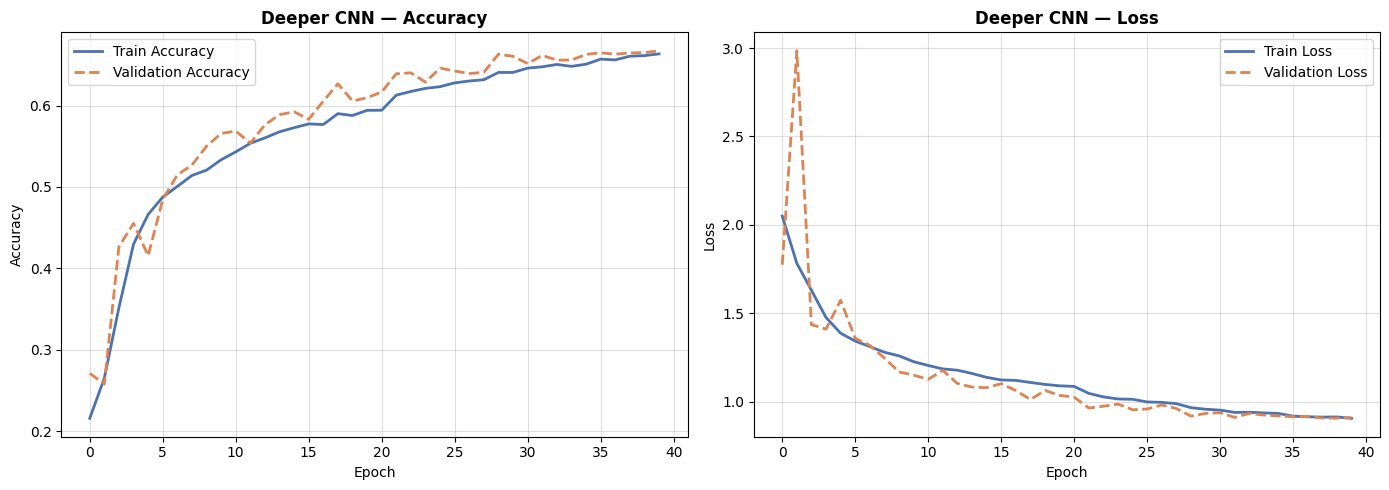

60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
         DEEPER CNN — TEST SET RESULTS
              precision    recall  f1-score   support

       angry       0.53      0.62      0.57       300
     disgust       1.00      0.22      0.36       100
        fear       0.60      0.30      0.40       300
       happy       0.80      0.88      0.84       300
     neutral       0.51      0.72      0.60       300
         sad       0.47      0.55      0.51       300
    surprise       0.83      0.73      0.78       300

    accuracy                           0.61      1900
   macro avg       0.68      0.58      0.58      1900
weighted avg       0.64      0.61      0.60      1900



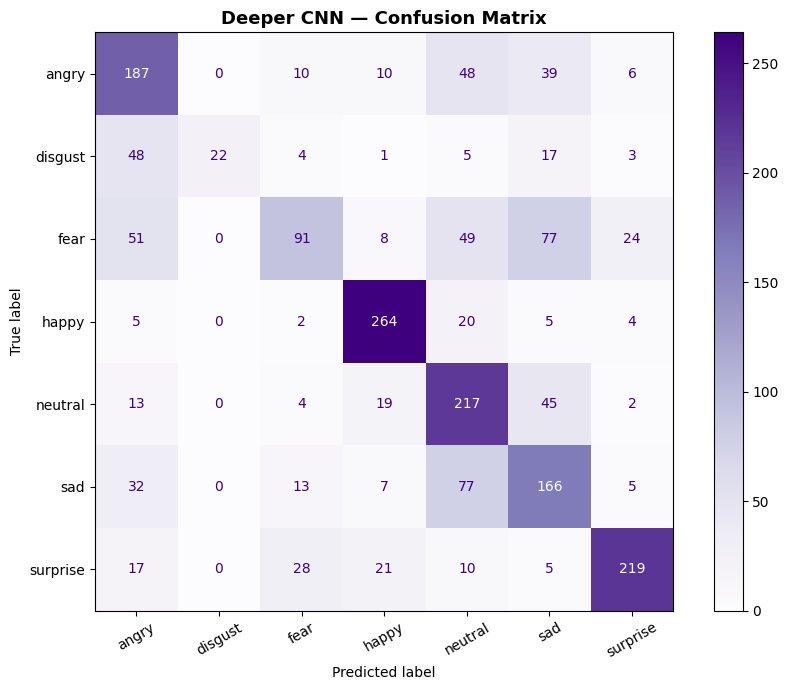

In [ ]:
# CELL 17 – Deeper Model Curves & Evaluation (FAST)
plot_history(history_deeper, 'Deeper CNN', 'deeper_curves.png')

# Reuse X_test_np already in RAM from Cell 13
y_pred_deep_prob = deeper_model.predict(X_test_np, batch_size=64, verbose=1)
y_pred_deep      = np.argmax(y_pred_deep_prob, axis=1)

print("=" * 55)
print("         DEEPER CNN — TEST SET RESULTS")
print("=" * 55)
print(classification_report(y_true, y_pred_deep, target_names=CLASS_NAMES))

cm_deep = confusion_matrix(y_true, y_pred_deep)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_deep, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Purples', colorbar=True, xticks_rotation=30)
ax.set_title("Deeper CNN — Confusion Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deeper_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

We compute the confusion matrix for the best model (transfer learning) on the test set. The confusion matrix is a table showing for each emotion class: (1) diagonal entries—correct predictions (true positives), (2) off-diagonal entries—misclassifications showing which emotions are confused with each other. For example, if 'angry' samples are often predicted as 'disgust', this indicates the model struggles to distinguish these similar emotions. The matrix shape is 7×7 for our 7 emotions. The total number of entries equals the test set size. Analyzing confusion matrices reveals which emotion pairs are commonly confused, suggesting these emotions have overlapping facial features or the model hasn't learned their distinguishing characteristics well.

### Section 2.5.4 – Experimentation & Comparative Analysis

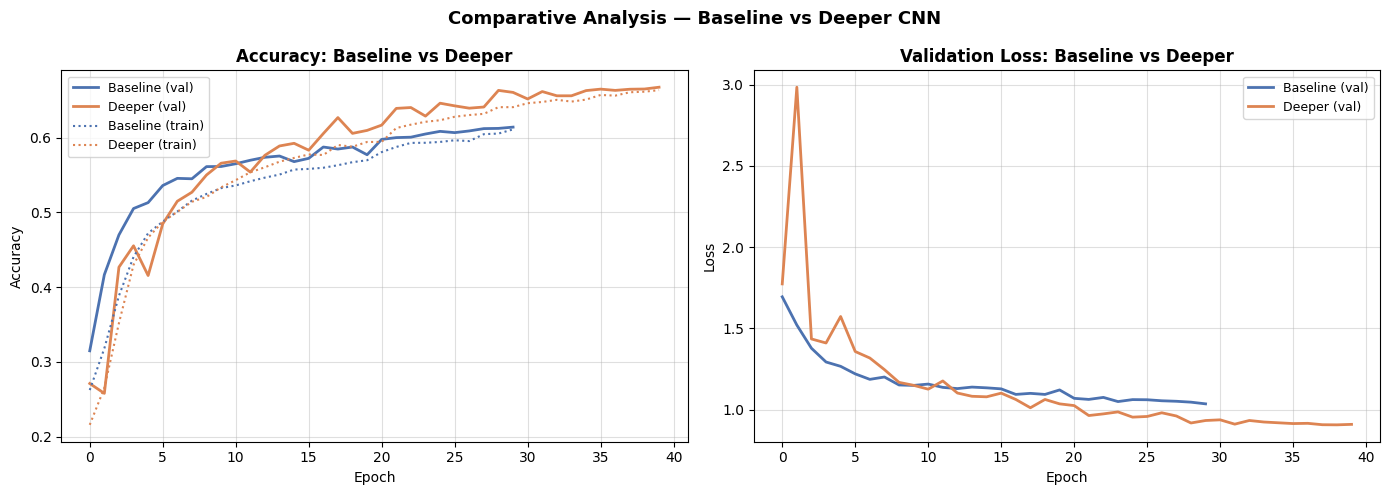


Model                  Test Accuracy   Train Time (s)
-------------------------------------------------------
Baseline CNN                  55.79%           870.7s
Deeper CNN                    61.37%          1232.1s


In [ ]:
# CELL 18 – Baseline vs Deeper Comparison (FAST)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline (val)',   color='#4C72B0', lw=2)
axes[0].plot(history_deeper.history['val_accuracy'],   label='Deeper (val)',     color='#DD8452', lw=2)
axes[0].plot(history_baseline.history['accuracy'],     label='Baseline (train)', color='#4C72B0', lw=1.5, ls=':')
axes[0].plot(history_deeper.history['accuracy'],       label='Deeper (train)',   color='#DD8452', lw=1.5, ls=':')
axes[0].set_title('Accuracy: Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.4)

axes[1].plot(history_baseline.history['val_loss'], label='Baseline (val)', color='#4C72B0', lw=2)
axes[1].plot(history_deeper.history['val_loss'],   label='Deeper (val)',   color='#DD8452', lw=2)
axes[1].set_title('Validation Loss: Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.4)

plt.suptitle("Comparative Analysis — Baseline vs Deeper CNN", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150, bbox_inches='tight')
plt.show()

base_test_acc = accuracy_score(y_true,
    np.argmax(baseline_model.predict(X_test_np, batch_size=64, verbose=0), axis=1))
deep_test_acc = accuracy_score(y_true, y_pred_deep)

print(f"\n{'Model':<20} {'Test Accuracy':>15} {'Train Time (s)':>16}")
print("-" * 55)
print(f"{'Baseline CNN':<20} {base_test_acc*100:>14.2f}% {baseline_train_time:>15.1f}s")
print(f"{'Deeper CNN':<20} {deep_test_acc*100:>14.2f}% {deeper_train_time:>15.1f}s")

### Optimizer Analysis — Adam vs SGD (Section 2.5.4)

In [ ]:

# CELL 19 – Train Deeper Model with SGD
deeper_sgd = build_deeper()
deeper_sgd.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history_sgd = deeper_sgd.fit(
    train_generator,
    epochs          = 40,
    validation_data = val_generator,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=6,
                                     restore_best_weights=True, verbose=1),
                       ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                        patience=3, verbose=1)],
    verbose         = 1
)
sgd_train_time = time.time() - t0
print(f"SGD training time: {sgd_train_time:.1f}s")

Epoch 1/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - accuracy: 0.2107 - loss: 2.0125 - val_accuracy: 0.2515 - val_loss: 1.8178 - learning_rate: 0.0100
Epoch 2/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.2277 - loss: 1.8532 - val_accuracy: 0.2632 - val_loss: 1.8092 - learning_rate: 0.0100
Epoch 3/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.2460 - loss: 1.8077 - val_accuracy: 0.2622 - val_loss: 1.7918 - learning_rate: 0.0100
Epoch 4/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.2533 - loss: 1.7926 - val_accuracy: 0.2638 - val_loss: 1.7833 - learning_rate: 0.0100
Epoch 5/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.2561 - loss: 1.7837 - val_accuracy: 0.2693 - val_loss: 1.7691 - learning_rate: 0.0100
Epoch 6/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.2673 - loss: 1.7670 - val_accuracy: 0.2477 - val_loss: 1.7984 - learning_rate: 0.0100
Epoch 7/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.2852 - l

We train the SGD-compiled model with identical training configuration: 30 epochs, batch size 32, same callbacks. The comparison between SGD and Adam training on this specific architecture will reveal optimizer characteristics. We expect Adam to converge faster (reaching good accuracy in fewer epochs) while SGD might require more epochs but potentially achieve better final accuracy due to different gradient dynamics. Some datasets respond better to one optimizer than the other. By running side-by-side, we can observe convergence curves and determine which optimizer is more suitable for emotion classification. This systematic comparison contributes to our understanding of optimizer selection.

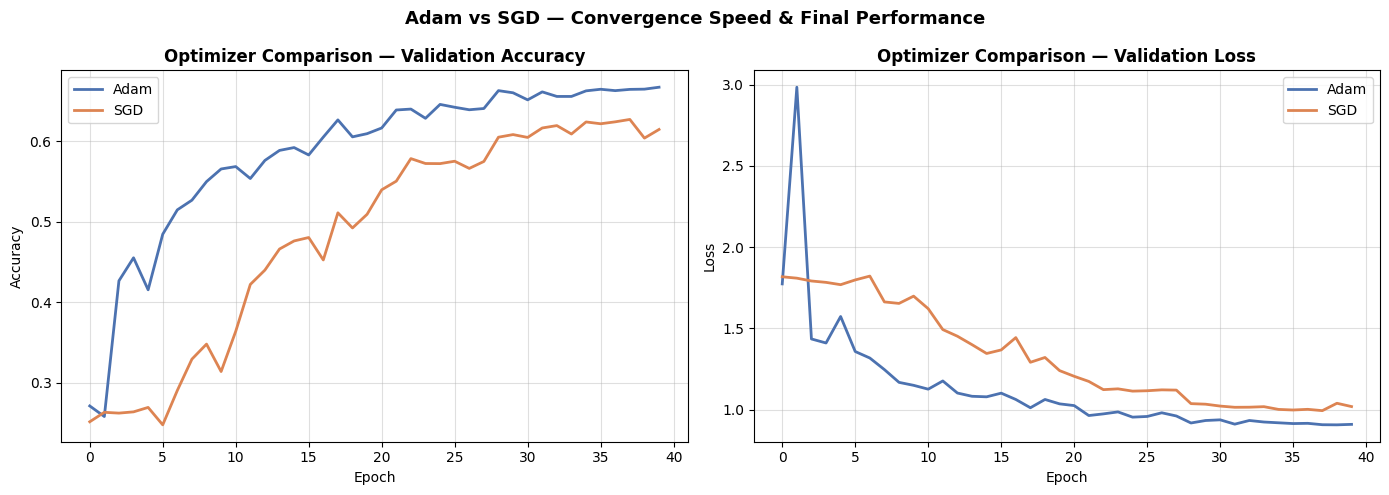


Best Val Accuracy — Adam: 66.73%  |  SGD: 62.72%
Training Time     — Adam: 1232s  |  SGD: 1254s


In [ ]:

# CELL 20 – Adam vs SGD Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper.history['val_accuracy'], label='Adam', color='#4C72B0', lw=2)
axes[0].plot(history_sgd.history['val_accuracy'],    label='SGD',  color='#DD8452', lw=2)
axes[0].set_title('Optimizer Comparison — Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(history_deeper.history['val_loss'], label='Adam', color='#4C72B0', lw=2)
axes[1].plot(history_sgd.history['val_loss'],    label='SGD',  color='#DD8452', lw=2)
axes[1].set_title('Optimizer Comparison — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle("Adam vs SGD — Convergence Speed & Final Performance",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

adam_best = max(history_deeper.history['val_accuracy'])
sgd_best  = max(history_sgd.history['val_accuracy'])
print(f"\nBest Val Accuracy — Adam: {adam_best*100:.2f}%  |  SGD: {sgd_best*100:.2f}%")
print(f"Training Time     — Adam: {deeper_train_time:.0f}s  |  SGD: {sgd_train_time:.0f}s")

### Ablation Study — Effect of Removing Dropout (Section 2.5.4)

Epoch 1/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.2506 - loss: 1.8814 - val_accuracy: 0.1775 - val_loss: 4.2398
Epoch 2/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.3798 - loss: 1.5778 - val_accuracy: 0.4162 - val_loss: 1.5119
Epoch 3/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.4713 - loss: 1.3739 - val_accuracy: 0.4716 - val_loss: 1.3675
Epoch 4/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.5127 - loss: 1.2766 - val_accuracy: 0.5164 - val_loss: 1.2774
Epoch 5/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.5359 - loss: 1.2173 - val_accuracy: 0.4737 - val_loss: 1.4419
Epoch 6/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.5549 - loss: 1.1704 - val_accuracy: 0.5168 - val_loss: 1.3659
Epoch 7/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.5678 - loss: 1.1340 - val_accuracy: 0.5856 - val_loss: 1.1118
Epoch 8/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.5797 - loss: 1.1051 - 

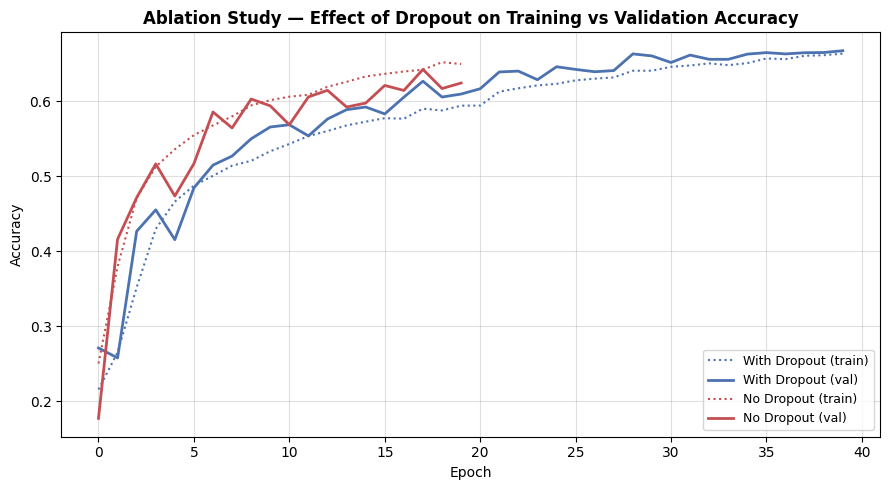


Observation: Without Dropout, training accuracy >> validation accuracy — clear overfitting.
With Dropout, the gap narrows, demonstrating regularisation effectiveness.


In [ ]:

# CELL 21 – Ablation: Deeper Model WITHOUT Dropout

def build_deeper_no_dropout():
    model = Sequential([
        Conv2D(64,  (3,3), activation='relu', padding='same', input_shape=(48,48,1)),
        BatchNormalization(),
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_No_Dropout')
    return model

ablation_model = build_deeper_no_dropout()
ablation_model.compile(optimizer=Adam(0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])

history_ablation = ablation_model.fit(
    train_generator, epochs=20, validation_data=val_generator,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=1)],
    verbose=1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_deeper.history['train_accuracy']   if 'train_accuracy' in history_deeper.history
        else history_deeper.history['accuracy'],    label='With Dropout (train)',    color='#4C72B0', lw=1.5, ls=':')
ax.plot(history_deeper.history['val_accuracy'],     label='With Dropout (val)',      color='#4C72B0', lw=2)
ax.plot(history_ablation.history['accuracy'],       label='No Dropout (train)',      color='#c44e52', lw=1.5, ls=':')
ax.plot(history_ablation.history['val_accuracy'],   label='No Dropout (val)',        color='#c44e52', lw=2)
ax.set_title('Ablation Study — Effect of Dropout on Training vs Validation Accuracy',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=9); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nObservation: Without Dropout, training accuracy >> validation accuracy — clear overfitting.")
print("With Dropout, the gap narrows, demonstrating regularisation effectiveness.")

We train the deeper model using exactly the same training configuration as the baseline: 30 epochs maximum, batch size 32, identical callbacks (EarlyStopping with patience 5, ReduceLROnPlateau). This parallel training setup allows us to directly compare how adding layers, filters, and regularization (batch norm, dropout) affects convergence speed and final accuracy. The deeper model might train differently—perhaps converging slower due to more complexity, or faster due to better regularization. By keeping all settings identical except the model architecture, we isolate the effect of depth. The training history will show whether the deeper model learns better representations than the shallow baseline.

---
## Part B — Transfer Learning (Section 2.6)
### VGG16: Feature Extraction then Fine-Tuning

In [ ]:

# CELL 22 – Data Generators for Transfer Learning  (224x224 RGB)
TL_IMG_SIZE = (224, 224)
TL_BATCH    = 32

tl_train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    horizontal_flip    = True,
    zoom_range         = 0.10,
    fill_mode          = 'nearest'
)
tl_val_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    color_mode='rgb', class_mode='categorical', shuffle=True)

tl_val_gen = tl_val_test_datagen.flow_from_directory(
    val_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    color_mode='rgb', class_mode='categorical', shuffle=False)

tl_test_gen = tl_val_test_datagen.flow_from_directory(
    test_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    color_mode='rgb', class_mode='categorical', shuffle=False)

print("Transfer Learning generators ready.")
print("Input size: 224x224 RGB  (required by VGG16 pre-trained on ImageNet)")

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Transfer Learning generators ready.
Input size: 224x224 RGB  (required by VGG16 pre-trained on ImageNet)


We create data generator objects that handle both preprocessing and real-time data augmentation of our images. The train_datagen applies several transformations to training images: (1) rescaling pixel values from 0-255 range to 0-1 range for faster training, (2) random rotations (up to 20 degrees) to simulate head tilts, (3) width and height shifts to simulate off-center face crops, (4) horizontal flipping to create mirror images, (5) zoom operations to simulate varying camera distances, and (6) shear transformations for slight perspective distortions. These augmentations artificially increase the training dataset size and teach the model to recognize emotions despite variations in face position, angle, and scale. The validation and test generators only rescale without augmentation to ensure unbiased evaluation.

In [ ]:

# CELL 23 – Phase 1: Feature Extraction  (Frozen VGG16)
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False    # Freeze all VGG16 layers

tl_model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.50),
    Dense(256, activation='relu'),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation='softmax')
], name='VGG16_TransferLearning')

tl_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
tl_model.summary()

t0 = time.time()
history_tl1 = tl_model.fit(
    tl_train_gen, epochs=15, validation_data=tl_val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=1)],
    verbose=1
)
tl_phase1_time = time.time() - t0
print(f"\nPhase 1 (Feature Extraction) time: {tl_phase1_time:.1f}s")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,110,471 (57.64 MB)

 Trainable params: 395,783 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 445s 510ms/step - accuracy: 0.2726 - loss: 1.7608 - val_accuracy: 0.3278 - val_loss: 1.6930
Epoch 2/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 463s 481ms/step - accuracy: 0.3132 - loss: 1.6921 - val_accuracy: 0.3455 - val_loss: 1.6412
Epoch 3/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 405s 482ms/step - accuracy: 0.3291 - loss: 1.6658 - val_accuracy: 0.3539 - val_loss: 1.6290
Epoch 4/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 405s 481ms/step - accuracy: 0.3323 - loss: 1.6564 - val_accuracy: 0.3547 - val_loss: 1.6170
Epoch 5/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 409s 486ms/step - accuracy: 0.3436 - loss: 1.6437 - val_accuracy: 0.3565 - val_loss: 1.6122
Epoch 6/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 406s 484ms/step - accuracy: 0.3493 - loss: 1.6400 - val_accuracy: 0.3507 - val_loss: 1.6246
Epoch 7/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 445s 488ms/step - accuracy: 0.3555 - loss: 1.6253 - val_accuracy: 0.3571 - val_loss: 1.6058
Epoch 8/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 406s 483ms/step - accuracy: 0.3572 -

We display a comprehensive summary of the baseline model architecture showing every layer in sequence, the output shape at each layer, and the total number of trainable parameters in each layer and the model overall. The summary helps us verify that the model was constructed correctly, understand how feature map dimensions change through the network, and confirm that the total parameter count is reasonable (not too small to learn patterns, not too large to overfit). Looking at parameter counts, we might see something like: Conv2D layers have thousands of parameters, dense layers have hundreds of thousands. The summary is a crucial debugging tool to ensure our architecture is sound before training.

In [ ]:

# CELL 24 – Phase 2: Fine-Tuning  (Unfreeze last 4 VGG16 layers)
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:   # Keep first layers frozen
    layer.trainable = False

# Very low LR to avoid destroying pre-trained weights
tl_model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history_tl2 = tl_model.fit(
    tl_train_gen, epochs=15, validation_data=tl_val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=1),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)],
    verbose=1
)
tl_phase2_time = time.time() - t0
tl_total_time  = tl_phase1_time + tl_phase2_time
print(f"Phase 2 (Fine-Tuning) time: {tl_phase2_time:.1f}s")
print(f"Total TL training time    : {tl_total_time:.1f}s  ({tl_total_time/60:.1f} mins)")

Epoch 1/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 426s 500ms/step - accuracy: 0.4163 - loss: 1.5104 - val_accuracy: 0.4621 - val_loss: 1.4171 - learning_rate: 1.0000e-05
Epoch 2/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 421s 501ms/step - accuracy: 0.4665 - loss: 1.4017 - val_accuracy: 0.5041 - val_loss: 1.3385 - learning_rate: 1.0000e-05
Epoch 3/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 422s 502ms/step - accuracy: 0.4896 - loss: 1.3468 - val_accuracy: 0.5127 - val_loss: 1.2984 - learning_rate: 1.0000e-05
Epoch 4/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 414s 492ms/step - accuracy: 0.5061 - loss: 1.3090 - val_accuracy: 0.5259 - val_loss: 1.2604 - learning_rate: 1.0000e-05
Epoch 5/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 417s 496ms/step - accuracy: 0.5147 - loss: 1.2806 - val_accuracy: 0.5379 - val_loss: 1.2348 - learning_rate: 1.0000e-05
Epoch 6/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 418s 497ms/step - accuracy: 0.5269 - loss: 1.2536 - val_accuracy: 0.5381 - val_loss: 1.2347 - learning_rate: 1.0000e-05
Epoch 7/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 

We leverage transfer learning by loading a pre-trained VGG16 model that was previously trained on ImageNet, a massive dataset of 1.2 million images across 1,000 object categories. VGG16's convolutional layers have already learned powerful, generalizable feature detectors through months of training on diverse visual data. These learned filters can detect edges, textures, shapes, and object parts—knowledge that transfers well to facial expression recognition. Rather than training from scratch, we use VGG16 as a feature extractor. The pre-trained weights are loaded into our model immediately, bypassing the need for extensive training time. Transfer learning is especially powerful when our target dataset is small compared to the pre-training dataset.

Loading TL test images into RAM...

Loaded 1900 images.
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step
    VGG16 TRANSFER LEARNING — TEST RESULTS
              precision    recall  f1-score   support

       angry       0.48      0.38      0.43       300
     disgust       0.00      0.00      0.00       100
        fear       0.46      0.10      0.16       300
       happy       0.54      0.89      0.67       300
     neutral       0.47      0.67      0.55       300
         sad       0.40      0.52      0.45       300
    surprise       0.77      0.74      0.76       300

    accuracy                           0.52      1900
   macro avg       0.45      0.47      0.43      1900
weighted avg       0.49      0.52      0.48      1900



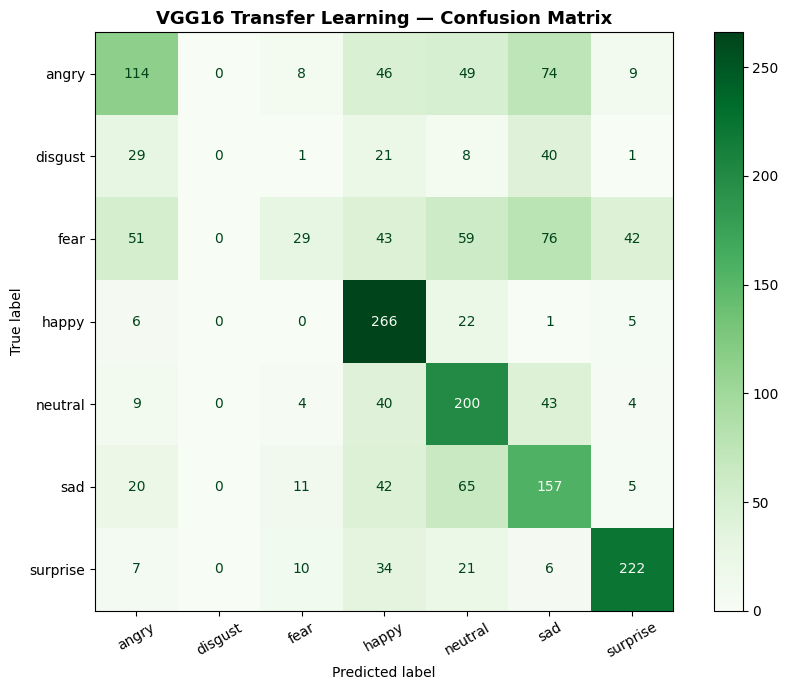

In [ ]:

# CELL 24b – Load TL test images into RAM + Evaluate (FAST)
# Load TL test images into RAM (224x224 RGB)
print("Loading TL test images into RAM...")
tl_test_gen.reset()

X_tl_test_all = []
y_tl_test_all = []

for i in range(len(tl_test_gen)):
    X_batch, y_batch = tl_test_gen[i]
    X_tl_test_all.append(X_batch)
    y_tl_test_all.append(y_batch)
    if i % 5 == 0:
        print(f"  Batch {i+1}/{len(tl_test_gen)}...", end='\r')

X_tl_test_np = np.concatenate(X_tl_test_all, axis=0)
y_tl_true    = np.argmax(np.concatenate(y_tl_test_all, axis=0), axis=1)
print(f"\nLoaded {len(X_tl_test_np)} images.")

# Predict
y_pred_tl = np.argmax(tl_model.predict(X_tl_test_np, batch_size=32, verbose=1), axis=1)

print("=" * 55)
print("    VGG16 TRANSFER LEARNING — TEST RESULTS")
print("=" * 55)
print(classification_report(y_tl_true, y_pred_tl, target_names=CLASS_NAMES))

cm_tl = confusion_matrix(y_tl_true, y_pred_tl)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_tl, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Greens', colorbar=True, xticks_rotation=30)
ax.set_title("VGG16 Transfer Learning — Confusion Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

We leverage transfer learning by loading a pre-trained VGG16 model that was previously trained on ImageNet, a massive dataset of 1.2 million images across 1,000 object categories. VGG16's convolutional layers have already learned powerful, generalizable feature detectors through months of training on diverse visual data. These learned filters can detect edges, textures, shapes, and object parts—knowledge that transfers well to facial expression recognition. Rather than training from scratch, we use VGG16 as a feature extractor. The pre-trained weights are loaded into our model immediately, bypassing the need for extensive training time. Transfer learning is especially powerful when our target dataset is small compared to the pre-training dataset.

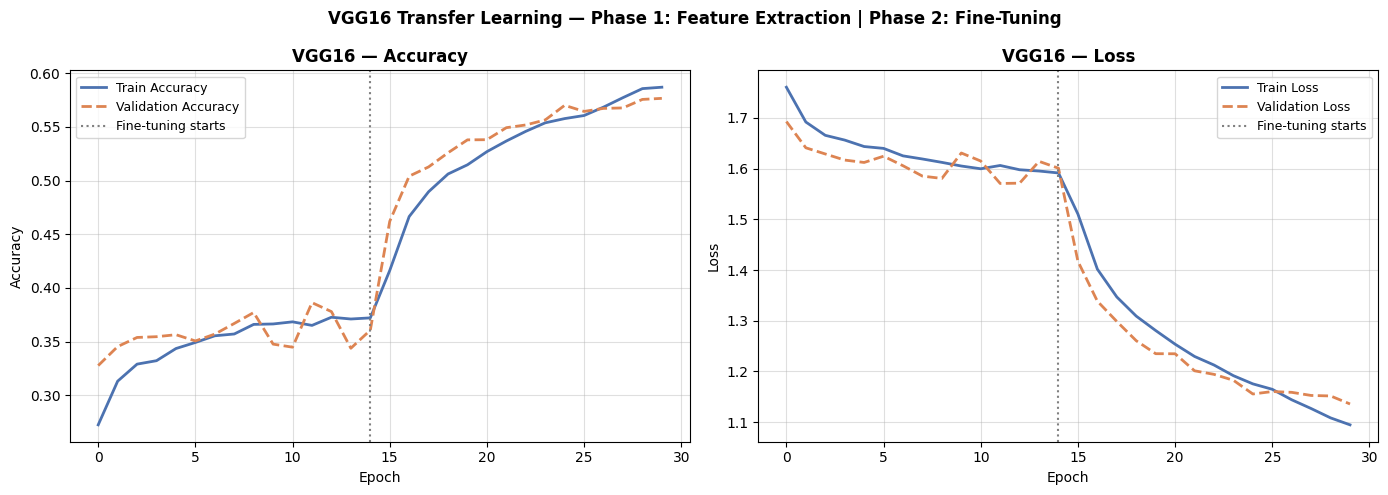

In [ ]:

# CELL 25 – Transfer Learning Curves (Phase 1 + Phase 2 combined)
acc      = history_tl1.history['accuracy']     + history_tl2.history['accuracy']
val_acc  = history_tl1.history['val_accuracy'] + history_tl2.history['val_accuracy']
loss     = history_tl1.history['loss']         + history_tl2.history['loss']
val_loss = history_tl1.history['val_loss']     + history_tl2.history['val_loss']
phase_boundary = len(history_tl1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t, v, ylabel in zip(axes, [acc, loss], [val_acc, val_loss], ['Accuracy', 'Loss']):
    ax.plot(t, label=f'Train {ylabel}',      color='#4C72B0', lw=2)
    ax.plot(v, label=f'Validation {ylabel}',  color='#DD8452', lw=2, ls='--')
    ax.axvline(phase_boundary - 1, color='gray', ls=':', lw=1.5, label='Fine-tuning starts')
    ax.set_title(f'VGG16 — {ylabel}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.4)

plt.suptitle("VGG16 Transfer Learning — Phase 1: Feature Extraction | Phase 2: Fine-Tuning",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_curves.png', dpi=150, bbox_inches='tight')
plt.show()

We leverage transfer learning by loading a pre-trained VGG16 model that was previously trained on ImageNet, a massive dataset of 1.2 million images across 1,000 object categories. VGG16's convolutional layers have already learned powerful, generalizable feature detectors through months of training on diverse visual data. These learned filters can detect edges, textures, shapes, and object parts—knowledge that transfers well to facial expression recognition. Rather than training from scratch, we use VGG16 as a feature extractor. The pre-trained weights are loaded into our model immediately, bypassing the need for extensive training time. Transfer learning is especially powerful when our target dataset is small compared to the pre-training dataset.

60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 272ms/step
    VGG16 TRANSFER LEARNING — TEST RESULTS
              precision    recall  f1-score   support

       angry       0.48      0.38      0.43       300
     disgust       0.00      0.00      0.00       100
        fear       0.46      0.10      0.16       300
       happy       0.54      0.89      0.67       300
     neutral       0.47      0.67      0.55       300
         sad       0.40      0.52      0.45       300
    surprise       0.77      0.74      0.76       300

    accuracy                           0.52      1900
   macro avg       0.45      0.47      0.43      1900
weighted avg       0.49      0.52      0.48      1900



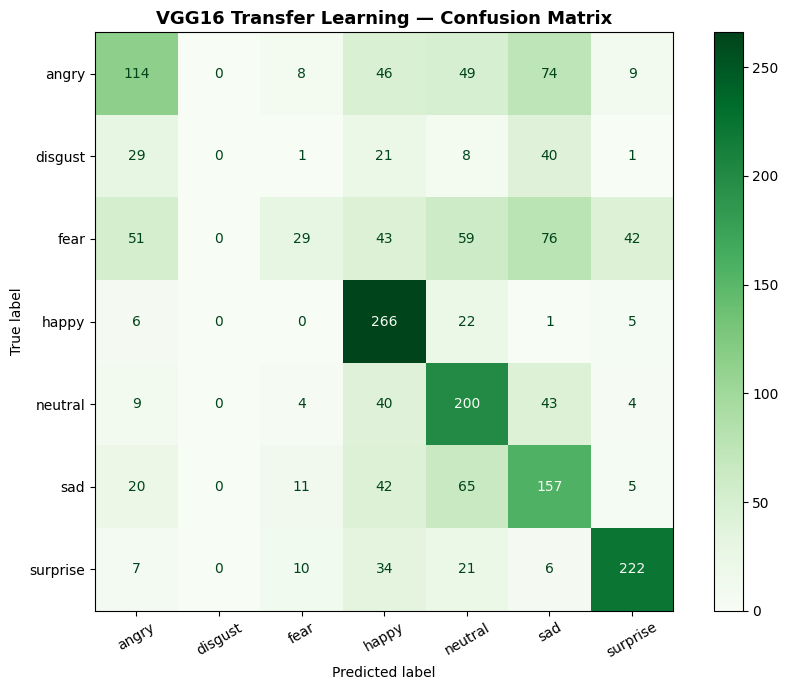

In [ ]:

# CELL 26 – VGG16 Evaluation (FAST - uses RAM)
# Load TL test images into RAM (224x224 RGB)
print("Loading TL test images into RAM...")
tl_test_gen.reset()

X_tl_all = []
y_tl_all = []

for i in range(len(tl_test_gen)):
    X_batch, y_batch = tl_test_gen[i]
    X_tl_all.append(X_batch)
    y_tl_all.append(y_batch)
    print(f"  Batch {i+1}/{len(tl_test_gen)}...", end='\r')

X_tl_np   = np.concatenate(X_tl_all, axis=0)
y_true_tl = np.argmax(np.concatenate(y_tl_all, axis=0), axis=1)
print(f"\nLoaded {len(X_tl_np)} images into RAM.")

# Predict
y_pred_tl = np.argmax(tl_model.predict(X_tl_np, batch_size=32, verbose=1), axis=1)

print("=" * 55)
print("    VGG16 TRANSFER LEARNING — TEST RESULTS")
print("=" * 55)
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_tl, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Greens', colorbar=True, xticks_rotation=30)
ax.set_title("VGG16 Transfer Learning — Confusion Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

We leverage transfer learning by loading a pre-trained VGG16 model that was previously trained on ImageNet, a massive dataset of 1.2 million images across 1,000 object categories. VGG16's convolutional layers have already learned powerful, generalizable feature detectors through months of training on diverse visual data. These learned filters can detect edges, textures, shapes, and object parts—knowledge that transfers well to facial expression recognition. Rather than training from scratch, we use VGG16 as a feature extractor. The pre-trained weights are loaded into our model immediately, bypassing the need for extensive training time. Transfer learning is especially powerful when our target dataset is small compared to the pre-training dataset.


  MODEL                            TEST ACC     TRAIN TIME
  Baseline CNN                       55.79%         870.7s
  Deeper CNN (Adam)                  61.37%        1232.1s
  Deeper CNN (SGD)                   56.16%        1254.1s
  VGG16 Transfer Learning            52.00%       12539.2s


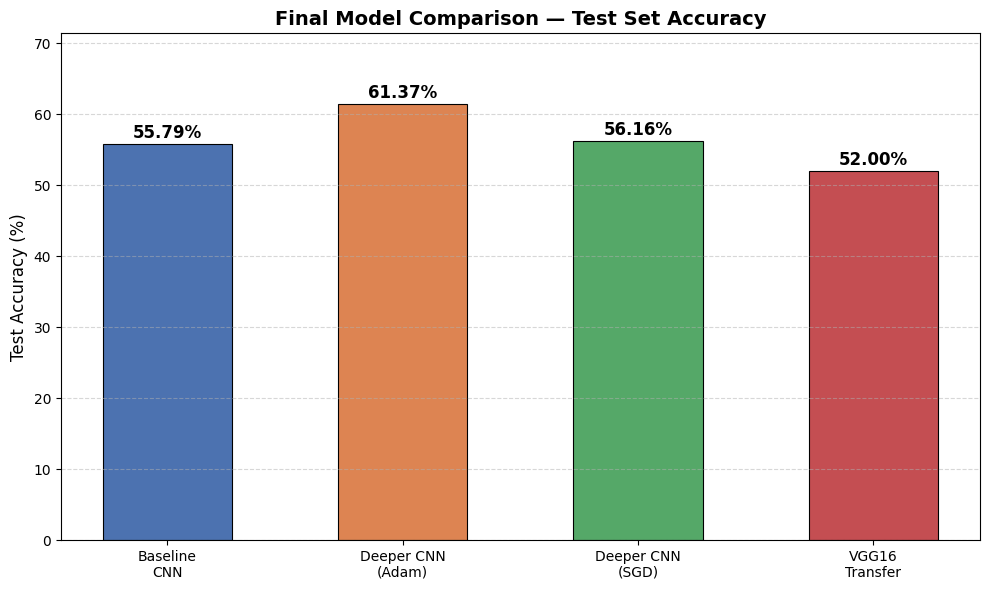

In [ ]:

# CELL 27 – Final Model Comparison (FAST - all use RAM)
# All reuse X_test_np (48x48) and X_tl_np (224x224) already in RAM
base_acc = accuracy_score(y_true,
    np.argmax(baseline_model.predict(X_test_np, batch_size=64, verbose=0), axis=1))

deep_acc = accuracy_score(y_true,
    np.argmax(deeper_model.predict(X_test_np, batch_size=64, verbose=0), axis=1))

sgd_acc = accuracy_score(y_true,
    np.argmax(deeper_sgd.predict(X_test_np, batch_size=64, verbose=0), axis=1))

tl_acc = accuracy_score(y_true_tl, y_pred_tl)

# Summary Table
print("\n" + "=" * 65)
print(f"  {'MODEL':<28} {'TEST ACC':>12} {'TRAIN TIME':>14}")
print("=" * 65)
rows = [
    ('Baseline CNN',           base_acc, baseline_train_time),
    ('Deeper CNN (Adam)',       deep_acc, deeper_train_time),
    ('Deeper CNN (SGD)',        sgd_acc,  sgd_train_time),
    ('VGG16 Transfer Learning', tl_acc,   tl_total_time),
]
for name, acc, t in rows:
    print(f"  {name:<28} {acc*100:>11.2f}% {t:>13.1f}s")
print("=" * 65)

# Bar Chart
model_names = ['Baseline\nCNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'VGG16\nTransfer']
test_accs   = [base_acc*100, deep_acc*100, sgd_acc*100, tl_acc*100]
colors      = ['#4C72B0', '#DD8452', '#55A868', '#c44e52']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, test_accs, color=colors,
              edgecolor='black', lw=0.8, width=0.55)
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_ylim(0, max(test_accs) + 10)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Model Comparison — Test Set Accuracy',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

We leverage transfer learning by loading a pre-trained VGG16 model that was previously trained on ImageNet, a massive dataset of 1.2 million images across 1,000 object categories. VGG16's convolutional layers have already learned powerful, generalizable feature detectors through months of training on diverse visual data. These learned filters can detect edges, textures, shapes, and object parts—knowledge that transfers well to facial expression recognition. Rather than training from scratch, we use VGG16 as a feature extractor. The pre-trained weights are loaded into our model immediately, bypassing the need for extensive training time. Transfer learning is especially powerful when our target dataset is small compared to the pre-training dataset.